# 🚁 VisDrone — YOLO Human & Car Detection + Counting
**Dataset:** [VisDrone Dataset on Kaggle](https://www.kaggle.com/datasets/banuprasadb/visdrone-dataset)

This notebook:
1. Installs Ultralytics YOLO
2. Filters VisDrone labels to keep only **people (class 1)** and **cars (class 4)**
3. Trains YOLOv8 on train split, validates on val split
4. Runs inference with **live human & car counts**


## 1. Install Dependencies

In [1]:
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


## 2. Explore Dataset Structure

In [2]:
from pathlib import Path

# ✅ Correct path found from diagnostic
BASE = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset'
WORK_DIR = Path('/kaggle/working/visdrone_filtered')

KEEP_CLASSES = {
    1: 0,   # pedestrian  → person
    2: 0,   # people      → person
    4: 1,   # car         → car
    5: 1,   # van         → car
    9: 1,   # bus         → car
}

# Verify
for split in ['VisDrone2019-DET-train', 'VisDrone2019-DET-val', 'VisDrone2019-DET-test-dev']:
    img_dir = Path(BASE) / split / 'images'
    lbl_dir = Path(BASE) / split / 'labels'
    n_imgs = len(list(img_dir.iterdir())) if img_dir.exists() else 0
    n_lbls = len(list(lbl_dir.iterdir())) if lbl_dir.exists() else 0
    print(f'{split}: {n_imgs} images, {n_lbls} labels')

VisDrone2019-DET-train: 6471 images, 6471 labels
VisDrone2019-DET-val: 548 images, 548 labels
VisDrone2019-DET-test-dev: 1610 images, 1610 labels


## 3. Filter Labels — Keep Only Person & Car

In [3]:
import shutil
from tqdm import tqdm

def filter_labels(src_label_dir, src_image_dir, dst_label_dir, dst_image_dir, keep_map):
    dst_label_dir = Path(dst_label_dir)
    dst_image_dir = Path(dst_image_dir)
    dst_label_dir.mkdir(parents=True, exist_ok=True)
    dst_image_dir.mkdir(parents=True, exist_ok=True)

    label_files = list(Path(src_label_dir).glob('*.txt'))
    kept, skipped = 0, 0

    for lbl_path in tqdm(label_files, desc=f'Filtering {Path(src_label_dir).parent.name}'):
        lines = lbl_path.read_text().strip().splitlines()
        new_lines = []
        for line in lines:
            parts = line.split()
            if not parts:
                continue
            cls = int(parts[0])
            if cls in keep_map:
                new_lines.append(f"{keep_map[cls]} {' '.join(parts[1:])}")

        if new_lines:
            (dst_label_dir / lbl_path.name).write_text('\n'.join(new_lines))
            for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
                img_src = Path(src_image_dir) / (lbl_path.stem + ext)
                if img_src.exists():
                    shutil.copy(img_src, dst_image_dir / img_src.name)
                    break
            kept += 1
        else:
            skipped += 1

    print(f'  → Kept: {kept} | Skipped: {skipped}')


SPLITS = {
    'train': 'VisDrone2019-DET-train',
    'val':   'VisDrone2019-DET-val',
    'test':  'VisDrone2019-DET-test-dev',
}

for split_key, split_folder in SPLITS.items():
    src_lbl = Path(BASE) / split_folder / 'labels'
    src_img = Path(BASE) / split_folder / 'images'
    if not src_lbl.exists():
        print(f'Skipping {split_folder} (no labels folder)')
        continue
    filter_labels(
        src_lbl, src_img,
        WORK_DIR / split_key / 'labels',
        WORK_DIR / split_key / 'images',
        KEEP_CLASSES
    )

print('\nDone! Verifying output:')
for split_key in ['train', 'val', 'test']:
    n = len(list((WORK_DIR / split_key / 'images').glob('*')))
    print(f'  {split_key}: {n} images copied')

Filtering VisDrone2019-DET-train: 100%|██████████| 6471/6471 [01:33<00:00, 69.49it/s]


  → Kept: 6136 | Skipped: 335


Filtering VisDrone2019-DET-val: 100%|██████████| 548/548 [00:07<00:00, 74.49it/s]


  → Kept: 531 | Skipped: 17


Filtering VisDrone2019-DET-test-dev: 100%|██████████| 1610/1610 [00:30<00:00, 52.15it/s]


  → Kept: 1490 | Skipped: 120

Done! Verifying output:
  train: 6136 images copied
  val: 531 images copied
  test: 1490 images copied


## 4. Create YAML Config

In [4]:
import yaml

WORK_DIR.mkdir(parents=True, exist_ok=True)

data_yaml = {
    'path': str(WORK_DIR),
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc': 2,
    'names': ['person', 'car']
}

yaml_path = WORK_DIR / 'visdrone_filtered.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print('YAML saved to:', yaml_path)
print(open(yaml_path).read())

YAML saved to: /kaggle/working/visdrone_filtered/visdrone_filtered.yaml
names:
- person
- car
nc: 2
path: /kaggle/working/visdrone_filtered
test: test/images
train: train/images
val: val/images



## 5. Visualize Sample Annotations (Sanity Check)

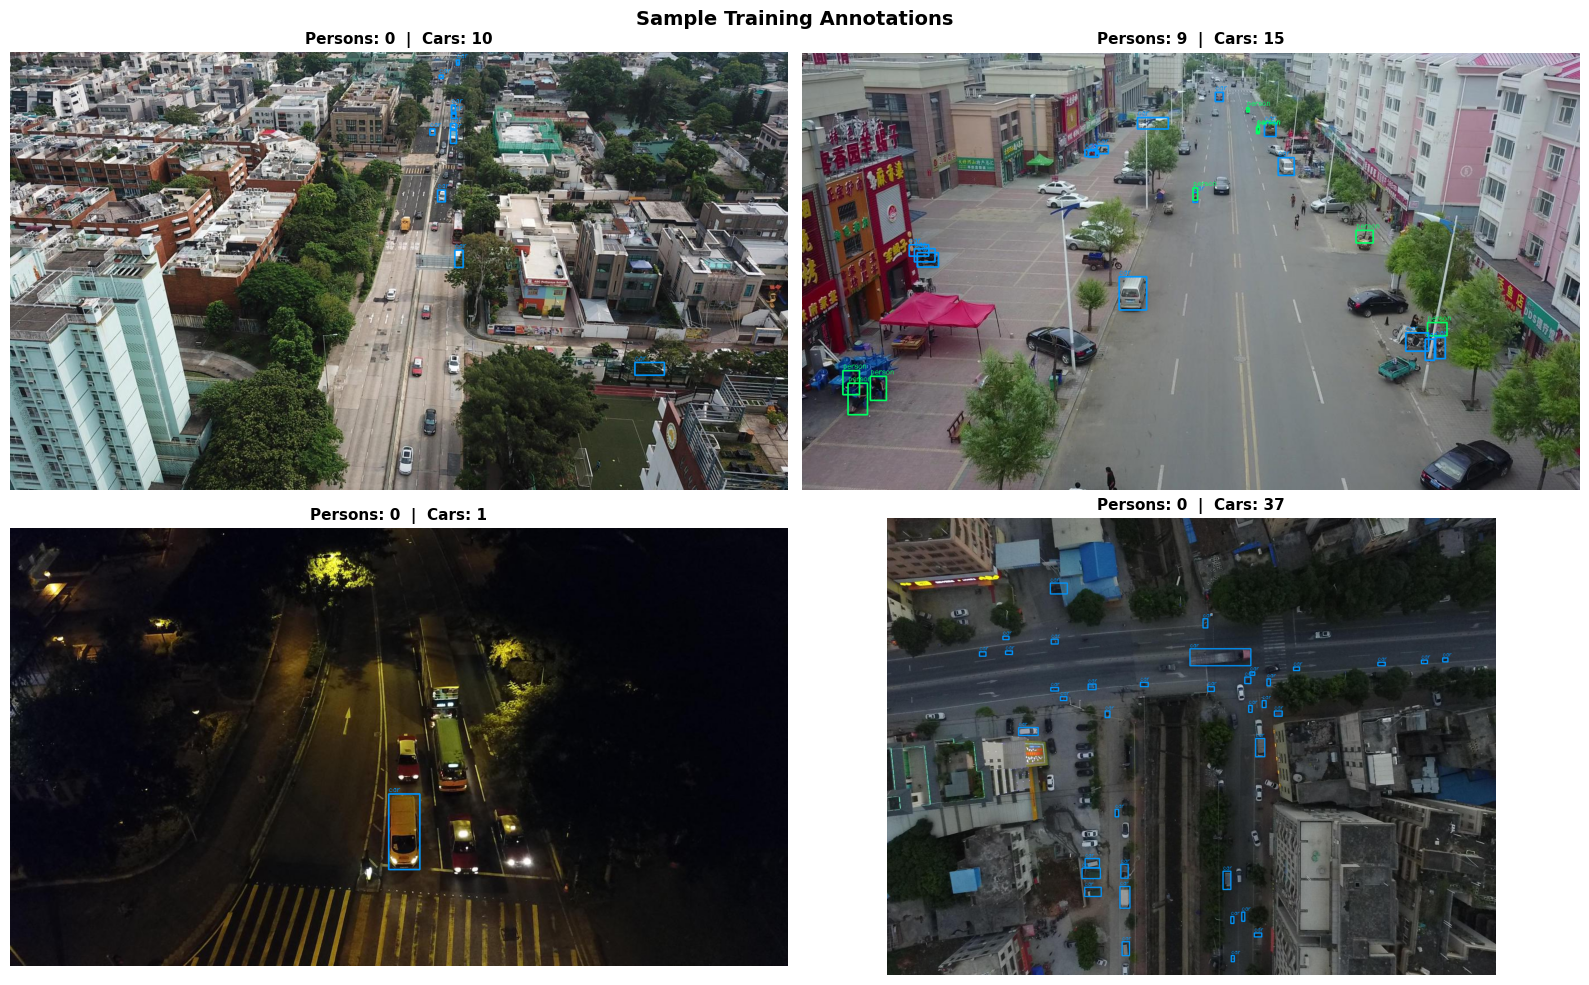

Sample saved.


In [5]:
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np

COLORS = [(0, 255, 100), (0, 150, 255)]  # person=green, car=blue
CLASS_NAMES = ['person', 'car']

def draw_boxes(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lines = Path(lbl_path).read_text().strip().splitlines()
    counts = {0: 0, 1: 0}
    for line in lines:
        cls, cx, cy, bw, bh = map(float, line.split())
        cls = int(cls)
        counts[cls] += 1
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), COLORS[cls], 2)
        cv2.putText(img, CLASS_NAMES[cls], (x1, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, COLORS[cls], 1)
    title = f"Persons: {counts[0]}  |  Cars: {counts[1]}"
    return img, title

# Pick 4 random training samples
img_files = list((WORK_DIR / 'train' / 'images').glob('*.jpg'))
samples = random.sample(img_files, min(4, len(img_files)))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, img_path in zip(axes.flatten(), samples):
    lbl_path = WORK_DIR / 'train' / 'labels' / (img_path.stem + '.txt')
    img, title = draw_boxes(img_path, lbl_path)
    ax.imshow(img)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Training Annotations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_annotations.png', dpi=120, bbox_inches='tight')
plt.show()
print('Sample saved.')

In [6]:
import os
from pathlib import Path

# Search for where the dataset actually is
print("=== Searching for VisDrone images ===")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith(('.jpg', '.png', '.jpeg')):
            print(os.path.join(root, f))
            break  # just show first image per folder
    if 'images' in dirs:
        print(f"Found 'images' folder at: {root}")

=== Searching for VisDrone images ===
Found 'images' folder at: /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-challenge
/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images/9999939_00000_d_0000208.jpg
Found 'images' folder at: /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev
/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/9999973_00000_d_0000028.jpg
Found 'images' folder at: /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train
/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train/images/9999951_00000_d_0000023.jpg
Found 'images' folder at: /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val
/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-v

## 6. Train YOLOv8

In [7]:

from ultralytics import YOLO

# Use yolov8s for a good speed/accuracy trade-off on Kaggle GPU (T4/P100)
# Options: yolov8n (fastest), yolov8s, yolov8m, yolov8l, yolov8x (most accurate)
model = YOLO('yolov8m.pt')

results = model.train(
    data=str(yaml_path),
    epochs=50,          # Increase to 100 for better accuracy
    imgsz=640,
    batch=16,           # Reduce to 8 if you hit OOM
    device=0,           # GPU; use 'cpu' if needed
    workers=4,
    project='/kaggle/working/runs',
    name='visdrone_person_car',
    exist_ok=True,

    # Augmentation — helpful for drone imagery
    mosaic=1.0,
    mixup=0.1,
    flipud=0.3,          # Drones can tilt
    degrees=10.0,
    scale=0.5,
    translate=0.2,

    # Optimization
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=3,
    cos_lr=True,
    patience=15,         # Early stopping

    # Logging
    plots=True,
    save=True,
    save_period=10,
    verbose=True,
)

print('Training complete!')
print('Best model saved at:', results.save_dir)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/visdrone_filtered/visdrone_filtered.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_person_car, nbs=64, nms=False, opset=None, optimize=False, optimizer=

In [8]:
from pathlib import Path
from ultralytics import YOLO

# ── Redefine paths after kernel restart ────────────────────────────────
WORK_DIR  = Path('/kaggle/working/visdrone_filtered')
yaml_path = WORK_DIR / 'visdrone_filtered.yaml'

# Verify it exists before training
if not yaml_path.exists():
    raise FileNotFoundError(f"YAML not found at {yaml_path}. Re-run the YAML cell first.")
print(f"YAML found: {yaml_path}")
print(open(yaml_path).read())

# ── Train ──────────────────────────────────────────────────────────────
model = YOLO('yolov8s.pt')

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    project='/kaggle/working/runs',
    name='visdrone_person_car',
    exist_ok=True,
    mosaic=1.0,
    mixup=0.1,
    flipud=0.3,
    degrees=10.0,
    scale=0.5,
    translate=0.2,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=3,
    cos_lr=True,
    patience=15,
    plots=True,
    save=True,
    save_period=10,
    verbose=True,
)

print('Training complete!')
print('Best model saved at:', results.save_dir)

YAML found: /kaggle/working/visdrone_filtered/visdrone_filtered.yaml
names:
- person
- car
nc: 2
path: /kaggle/working/visdrone_filtered
test: test/images
train: train/images
val: val/images

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/visdrone_filtered/visdrone_filtered.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask

## 7. Evaluate on Validation Set

In [9]:
best_model_path = '/kaggle/working/runs/visdrone_person_car/weights/best.pt'
model_eval = YOLO(best_model_path)

metrics = model_eval.val(
    data=str(yaml_path),
    imgsz=640,
    batch=16,
    device=0,
    split='val',
    plots=True,
    save_json=True,
)

print(f"\n{'='*50}")
print(f"mAP50      : {metrics.box.map50:.4f}")
print(f"mAP50-95   : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")
print('='*50)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2677.7±514.2 MB/s, size: 139.0 KB)
val: Scanning /kaggle/working/visdrone_filtered/val/labels.cache... 531 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 531/531 202.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 3.9it/s 8.7s0.2s
                   all        531      14023      0.476      0.366      0.352      0.157
                person        497       6412       0.43      0.282      0.267     0.0943
                   car        525       7611      0.521       0.45      0.438       0.22
Speed: 0.8ms preprocess, 5.0ms inference, 0.0ms loss, 3.7ms postprocess per image
Saving /kaggle/working/runs/detect/val/predictions.json...
Results saved to /kaggle/working/runs/detect/val

mAP50      : 

## 8. Plot Training Curves

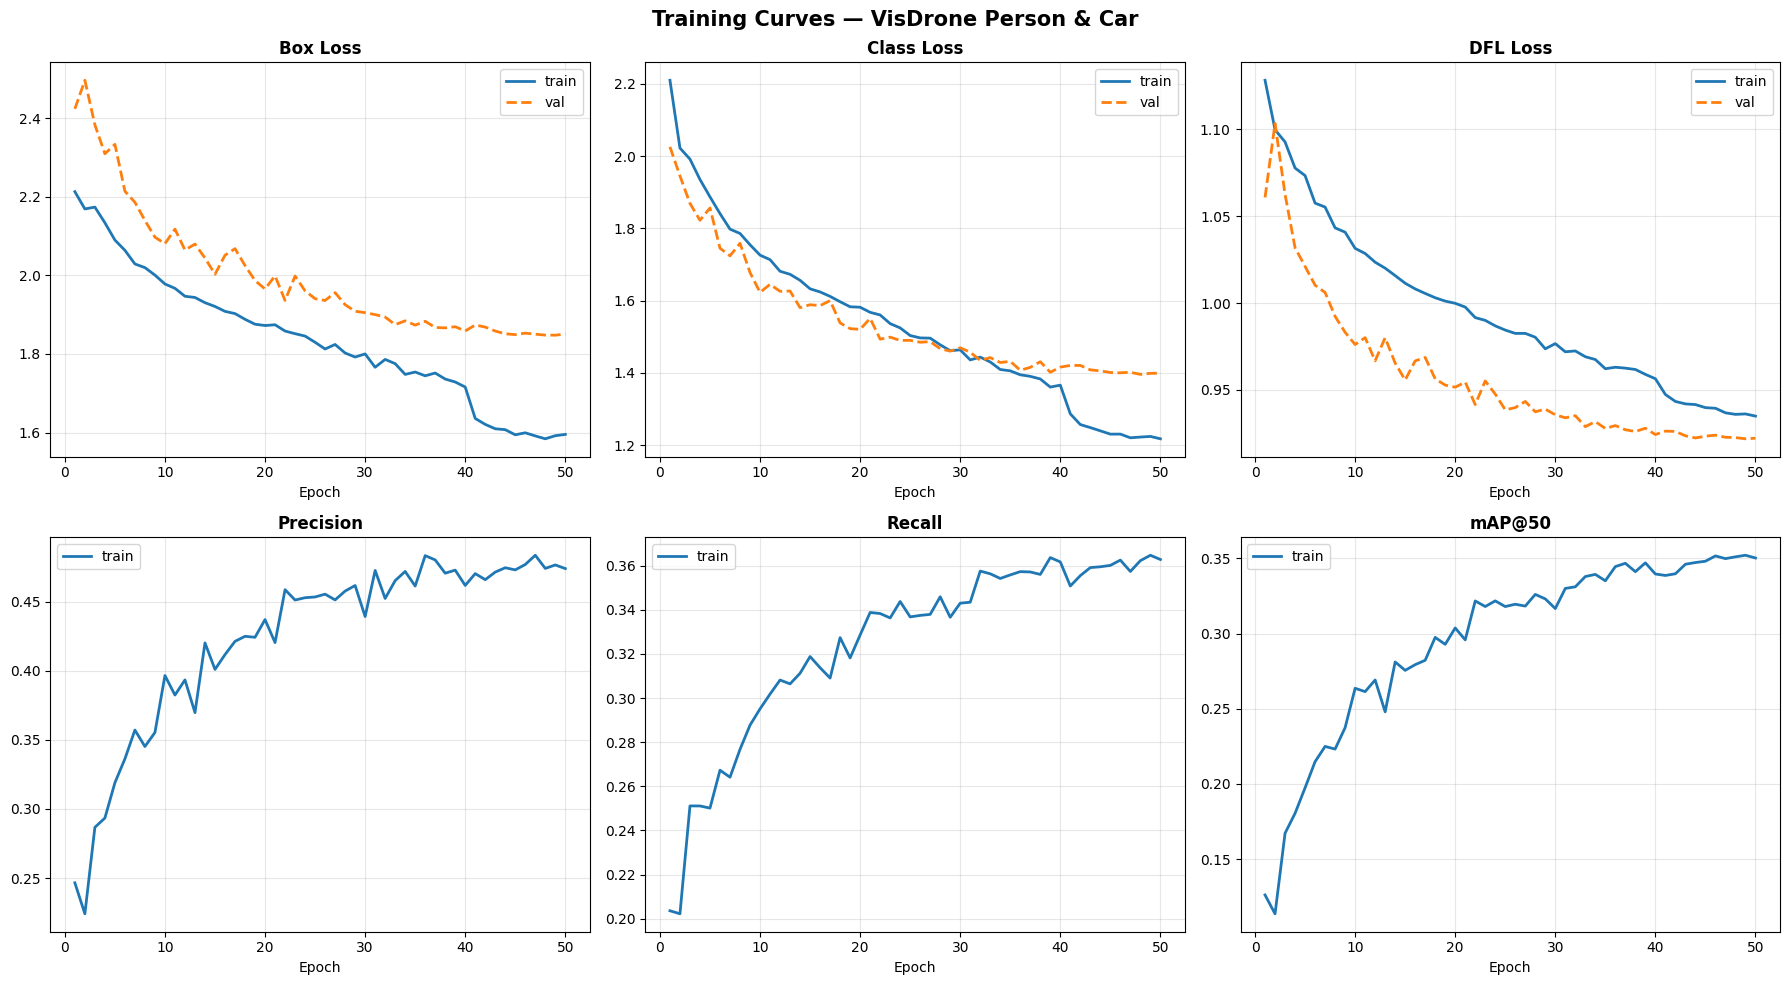

In [10]:
import pandas as pd

results_csv = '/kaggle/working/runs/visdrone_person_car/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Curves — VisDrone Person & Car', fontsize=15, fontweight='bold')

plot_pairs = [
    ('train/box_loss', 'val/box_loss', 'Box Loss'),
    ('train/cls_loss', 'val/cls_loss', 'Class Loss'),
    ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss'),
    ('metrics/precision(B)', None, 'Precision'),
    ('metrics/recall(B)',    None, 'Recall'),
    ('metrics/mAP50(B)',     None, 'mAP@50'),
]

for ax, (train_col, val_col, title) in zip(axes.flatten(), plot_pairs):
    if train_col in df.columns:
        ax.plot(df['epoch'], df[train_col], label='train', linewidth=2)
    if val_col and val_col in df.columns:
        ax.plot(df['epoch'], df[val_col], label='val', linewidth=2, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Inference with Human & Car Counting

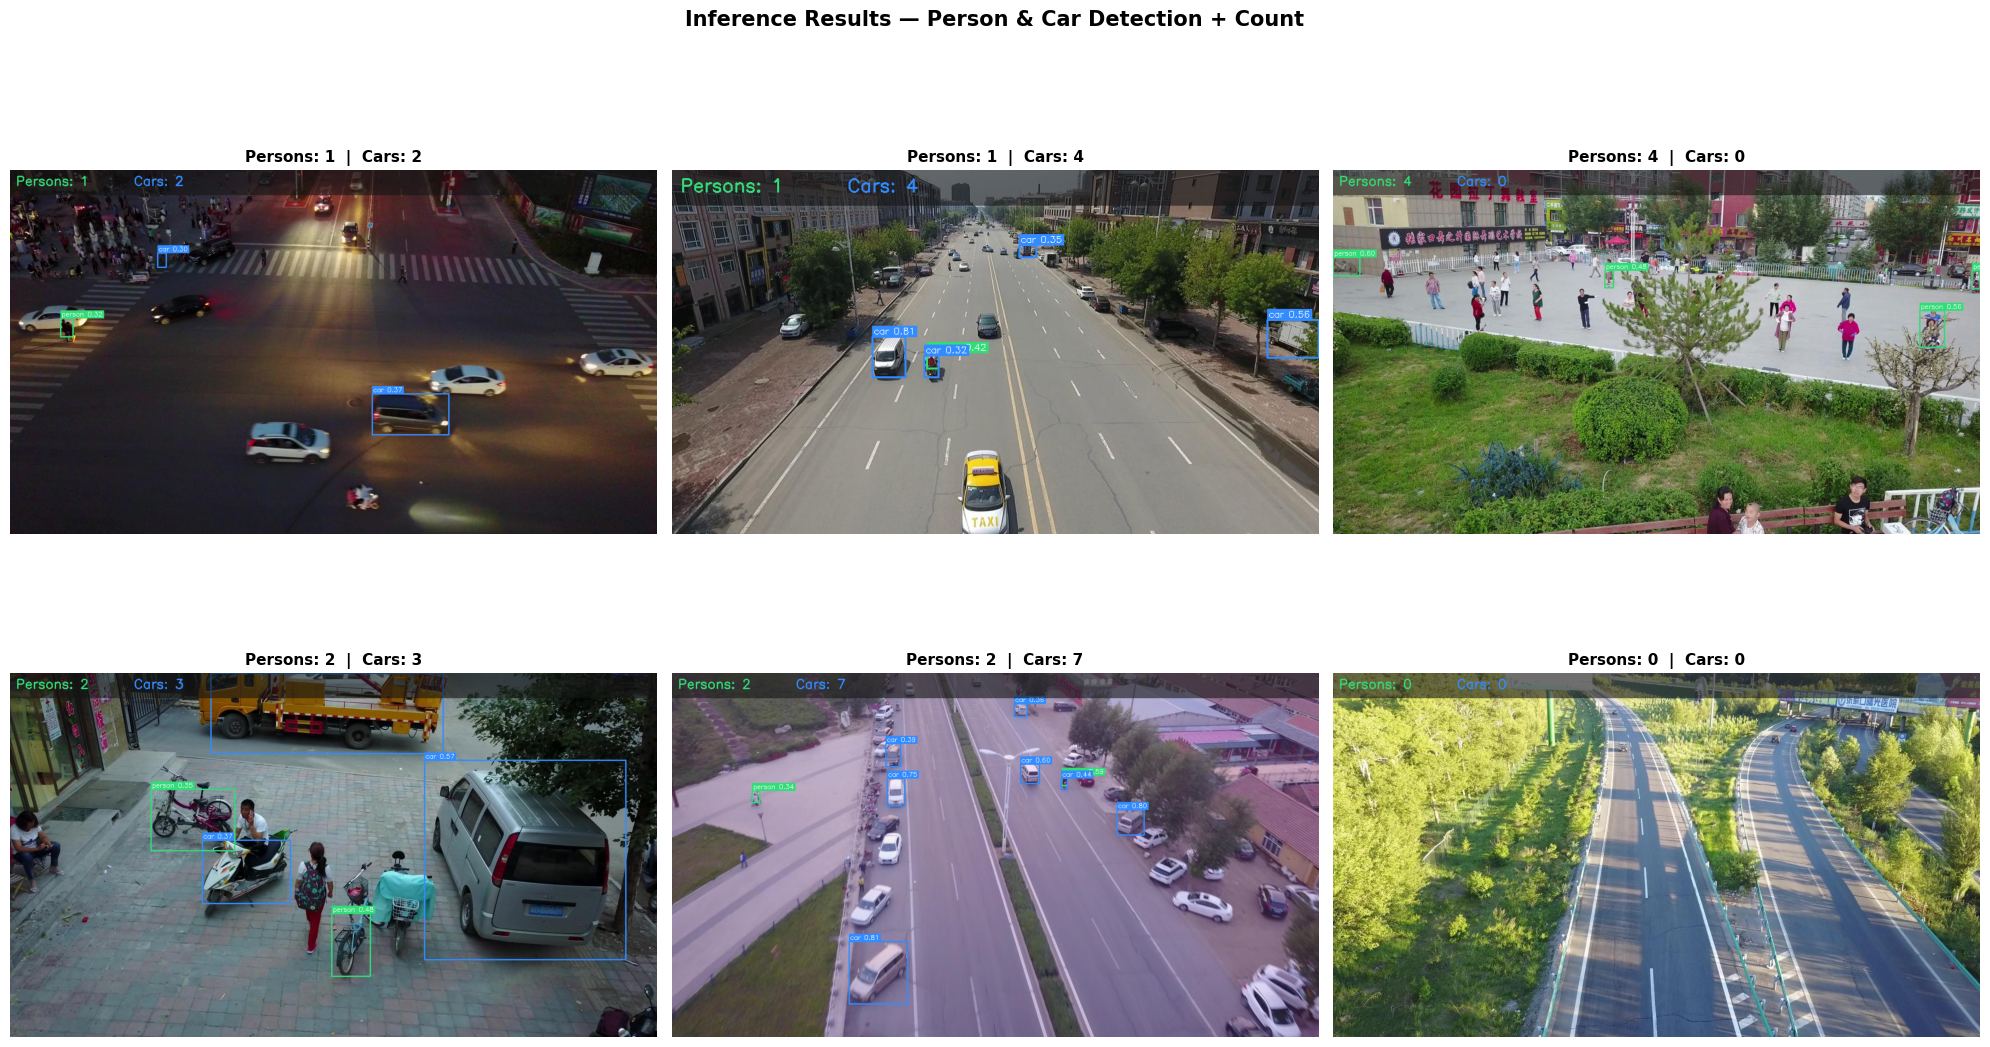

Inference results saved.


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def detect_and_count(model, image_path, conf=0.3, iou=0.5):
    """
    Run inference on a single image.
    Returns annotated image + counts dict.
    """
    result = model.predict(
        source=str(image_path),
        conf=conf,
        iou=iou,
        imgsz=640,
        verbose=False
    )[0]

    img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB).copy()
    h, w = img.shape[:2]

    CLASS_COLORS = [(50, 220, 120), (50, 140, 255)]  # person=green, car=blue
    CLASS_NAMES  = ['person', 'car']
    counts = {'person': 0, 'car': 0}

    boxes = result.boxes
    for box in boxes:
        cls   = int(box.cls[0])
        conf_ = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

        label = CLASS_NAMES[cls]
        counts[label] += 1
        color = CLASS_COLORS[cls]

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        txt = f'{label} {conf_:.2f}'
        (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(img, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
        cv2.putText(img, txt, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)

    # Count overlay (top-left banner)
    banner_h = 52
    overlay = img.copy()
    cv2.rectangle(overlay, (0, 0), (w, banner_h), (20, 20, 20), -1)
    img = cv2.addWeighted(overlay, 0.6, img, 0.4, 0)
    cv2.putText(img, f"Persons: {counts['person']}",
                (12, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (50, 220, 120), 2)
    cv2.putText(img, f"Cars: {counts['car']}",
                (260, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (50, 140, 255), 2)

    return img, counts


# Load best weights
model_infer = YOLO('/kaggle/working/runs/visdrone_person_car/weights/best.pt')

# Run on 6 validation images
val_imgs = list((WORK_DIR / 'val' / 'images').glob('*.jpg'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Inference Results — Person & Car Detection + Count', fontsize=15, fontweight='bold')

for ax, img_path in zip(axes.flatten(), val_imgs):
    annotated, counts = detect_and_count(model_infer, img_path)
    ax.imshow(annotated)
    ax.set_title(f"Persons: {counts['person']}  |  Cars: {counts['car']}",
                 fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/inference_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Inference results saved.')

## 10. Batch Counting — Summarise a Full Folder

In [12]:
from collections import defaultdict

def count_folder(model, folder, conf=0.3, max_images=None):
    """
    Run inference on every image in folder.
    Returns a DataFrame with per-image counts.
    """
    records = []
    images = list(Path(folder).glob('*.jpg'))
    if max_images:
        images = images[:max_images]

    for img_path in tqdm(images, desc='Counting'):
        _, counts = detect_and_count(model, img_path, conf=conf)
        records.append({'image': img_path.name, **counts})

    df = pd.DataFrame(records)
    return df


count_df = count_folder(
    model_infer,
    WORK_DIR / 'val' / 'images',
    conf=0.3,
    max_images=100   # Remove limit to process all
)

print(count_df.describe())
count_df.to_csv('/kaggle/working/val_counts.csv', index=False)
print('\nPer-image counts saved to val_counts.csv')
print(f"Total persons detected: {count_df['person'].sum()}")
print(f"Total cars detected   : {count_df['car'].sum()}")

Counting: 100%|██████████| 100/100 [00:02<00:00, 38.01it/s]

          person       car
count  100.00000  100.0000
mean     2.96000    6.8100
std      2.84949    4.9639
min      0.00000    0.0000
25%      1.00000    3.0000
50%      2.00000    6.0000
75%      4.00000    9.0000
max     15.00000   23.0000

Per-image counts saved to val_counts.csv
Total persons detected: 296
Total cars detected   : 681


## 12. Save Final Artefacts

In [13]:
import shutil

OUTPUT_DIR = Path('/kaggle/working/final_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Copy best weights
shutil.copy('/kaggle/working/runs/visdrone_person_car/weights/best.pt',
            OUTPUT_DIR / 'best.pt')
shutil.copy('/kaggle/working/runs/visdrone_person_car/weights/last.pt',
            OUTPUT_DIR / 'last.pt')

# Copy plots
for f in ['training_curves.png', 'inference_results.png',
          'sample_annotations.png', 'val_counts.csv']:
    src = Path('/kaggle/working') / f
    if src.exists():
        shutil.copy(src, OUTPUT_DIR / f)

print('Files saved to /kaggle/working/final_outputs:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(' ', f.name)

Files saved to /kaggle/working/final_outputs:
  best.pt
  inference_results.png
  last.pt
  sample_annotations.png
  training_curves.png
  val_counts.csv



**Predictioncounting visualizationprocessed images/results**


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from ultralytics import YOLO
import random
import pandas as pd

# ── Load your trained model ────────────────────────────────────────────
model = YOLO('/kaggle/working/runs/visdrone_person_car/weights/best.pt')

CLASS_NAMES  = ['person', 'car']
CLASS_COLORS = [(50, 220, 120), (50, 140, 255)]  # green=person, blue=car

# ══════════════════════════════════════════════════════════════════════
# PART 1 — Prediction Output (bounding boxes on images)
# ══════════════════════════════════════════════════════════════════════

def predict_image(model, img_path, conf=0.3):
    """Run inference and return annotated image + counts."""
    result = model.predict(str(img_path), conf=conf, iou=0.45,
                           imgsz=1280, verbose=False)[0]

    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB).copy()
    h, w = img.shape[:2]
    counts = {'person': 0, 'car': 0}

    for box in result.boxes:
        cls   = int(box.cls[0])
        conf_ = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        label = CLASS_NAMES[cls]
        color = CLASS_COLORS[cls]
        counts[label] += 1

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        txt = f'{label} {conf_:.2f}'
        (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(img, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
        cv2.putText(img, txt, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)

    # Count banner at top
    overlay = img.copy()
    cv2.rectangle(overlay, (0,0), (w, 55), (15,15,15), -1)
    img = cv2.addWeighted(overlay, 0.65, img, 0.35, 0)
    cv2.putText(img, f"Persons: {counts['person']}",
                (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (50,220,120), 2)
    cv2.putText(img, f"Cars: {counts['car']}",
                (300, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (50,140,255), 2)

    return img, counts


# Pick 6 random val images
val_imgs = random.sample(
    list((WORK_DIR / 'val' / 'images').glob('*.jpg')), 6
)

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('PART 1 — Prediction Outputs', fontsize=16, fontweight='bold')

all_results = []
for ax, img_path in zip(axes.flatten(), val_imgs):
    annotated, counts = predict_image(model, img_path)
    ax.imshow(annotated)
    ax.set_title(f"Persons: {counts['person']}  |  Cars: {counts['car']}",
                 fontsize=11, fontweight='bold')
    ax.axis('off')
    all_results.append({'image': img_path.name, **counts})

plt.tight_layout()
plt.savefig('/kaggle/working/prediction_outputs.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Prediction outputs saved.")


# ══════════════════════════════════════════════════════════════════════
# PART 2 — Counting Visualization (charts)
# ══════════════════════════════════════════════════════════════════════

# Run on 30 images to get meaningful chart data
sample_imgs = random.sample(
    list((WORK_DIR / 'val' / 'images').glob('*.jpg')),
    min(30, len(list((WORK_DIR / 'val' / 'images').glob('*.jpg'))))
)

records = []
for img_path in sample_imgs:
    _, counts = predict_image(model, img_path, conf=0.3)
    records.append({'image': img_path.stem[:15], **counts})

df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('PART 2 — Counting Visualization', fontsize=16, fontweight='bold')

# ── Chart 1: Per-image bar chart ──────────────────────────────────────
ax = axes[0]
x = range(len(df))
bars1 = ax.bar([i - 0.2 for i in x], df['person'], width=0.4,
               color='#32DC78', label='Person', alpha=0.85)
bars2 = ax.bar([i + 0.2 for i in x], df['car'], width=0.4,
               color='#3296FF', label='Car', alpha=0.85)
ax.set_title('Person & Car Count per Image', fontweight='bold')
ax.set_xlabel('Image Index')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(list(x))
ax.set_xticklabels([str(i+1) for i in x], fontsize=7)

# ── Chart 2: Total counts bar ─────────────────────────────────────────
ax = axes[1]
totals = [df['person'].sum(), df['car'].sum()]
colors = ['#32DC78', '#3296FF']
bars = ax.bar(['Person', 'Car'], totals, color=colors, alpha=0.85, width=0.5)
ax.set_title(f'Total Detections (across {len(df)} images)', fontweight='bold')
ax.set_ylabel('Total Count')
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.3)

# ── Chart 3: Distribution histogram ──────────────────────────────────
ax = axes[2]
ax.hist(df['person'], bins=10, color='#32DC78', alpha=0.7,
        label='Person', edgecolor='white')
ax.hist(df['car'], bins=10, color='#3296FF', alpha=0.7,
        label='Car', edgecolor='white')
ax.set_title('Count Distribution per Image', fontweight='bold')
ax.set_xlabel('Count per Image')
ax.set_ylabel('Number of Images')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/counting_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Counting visualization saved.")
print(f"\n📊 Summary over {len(df)} images:")
print(f"   Total persons detected : {df['person'].sum()}")
print(f"   Total cars detected    : {df['car'].sum()}")
print(f"   Avg persons per image  : {df['person'].mean():.1f}")
print(f"   Avg cars per image     : {df['car'].mean():.1f}")


# ══════════════════════════════════════════════════════════════════════
# PART 3 — Processed Images (original vs detected side by side)
# ══════════════════════════════════════════════════════════════════════

def side_by_side(img_path, model, conf=0.3):
    """Return original | detected side by side."""
    original = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    detected, counts = predict_image(model, img_path, conf=conf)

    # Resize both to same height
    H = 480
    scale = H / original.shape[0]
    W = int(original.shape[1] * scale)
    original_r = cv2.resize(original, (W, H))
    detected_r = cv2.resize(detected, (W, H))

    # Add labels
    divider = np.ones((H, 6, 3), dtype=np.uint8) * 200
    combined = np.hstack([original_r, divider, detected_r])

    cv2.putText(combined, 'ORIGINAL', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)
    cv2.putText(combined, 'DETECTED', (W + 16, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)

    return combined, counts


processed_imgs = random.sample(
    list((WORK_DIR / 'val' / 'images').glob('*.jpg')), 4
)

fig, axes = plt.subplots(4, 1, figsize=(20, 24))
fig.suptitle('PART 3 — Processed Images (Original vs Detected)',
             fontsize=16, fontweight='bold')

for ax, img_path in zip(axes, processed_imgs):
    combined, counts = side_by_side(img_path, model)
    ax.imshow(combined)
    ax.set_title(
        f"{img_path.name}  →  Persons: {counts['person']} | Cars: {counts['car']}",
        fontsize=10, fontweight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/processed_images.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Processed images saved.")


# ══════════════════════════════════════════════════════════════════════
# Save CSV summary
# ══════════════════════════════════════════════════════════════════════
df.to_csv('/kaggle/working/detection_counts.csv', index=False)
print("\n✅ All outputs saved:")
print("   /kaggle/working/prediction_outputs.png")
print("   /kaggle/working/counting_visualization.png")
print("   /kaggle/working/processed_images.png")
print("   /kaggle/working/detection_counts.csv")

ModuleNotFoundError: No module named 'ultralytics'